開始訓練... 模擬總時間: 20.0s | 擬合切斷點: 5.0s


100%|██████████| 5000/5000 [08:19<00:00, 10.01it/s]


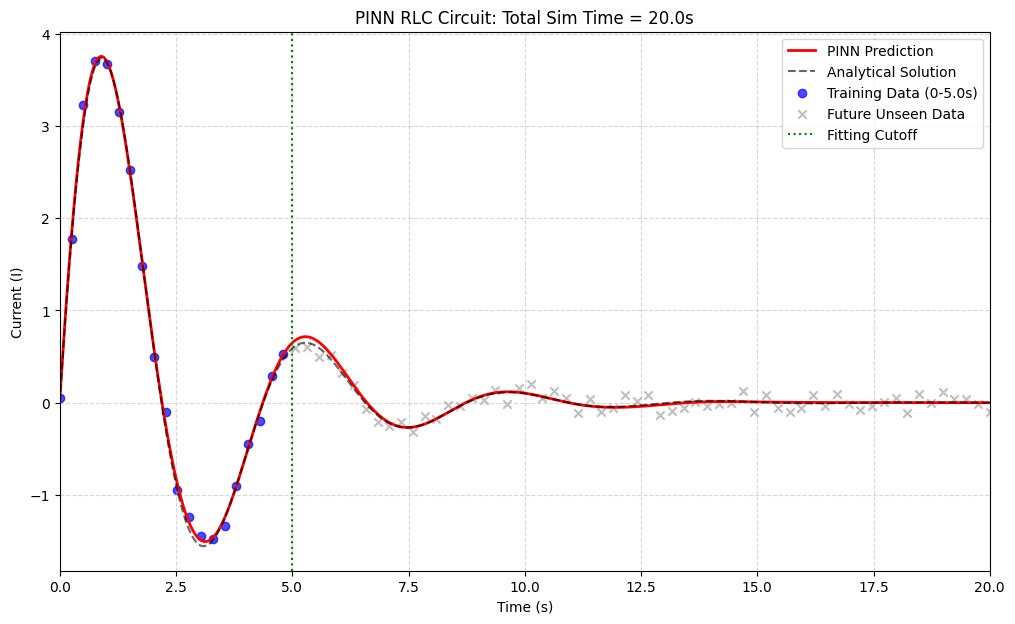

In [ ]:
# -*- coding: utf-8 -*-
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.initializers import RandomNormal
import math
from tqdm import trange

R = 1.2      # 電阻 (kohm)
L = 1.5      # 電感 (H)
C = 0.3      # 電容 (F)
VC_0 = 12.0  # 初始電壓 (V)

t_total = 20.0   # 總模擬時間
t_cutoff = 5.0   # 擬合切斷點

batch_size = 32
epochs = 5000
learning_rate = 0.001
weight_init = RandomNormal()

obs_points = int(t_total * 4)
t_obs_full = np.linspace(0, t_total, obs_points, dtype=np.float32).reshape(-1, 1)

alpha = R / (2 * L)
w0 = np.sqrt(1 / (L * C))
wd = np.sqrt(w0**2 - alpha**2)
i_true_full = (VC_0 / (L * wd)) * np.exp(-alpha * t_obs_full) * np.sin(wd * t_obs_full)
i_obs_full = i_true_full + 0.08 * np.random.normal(size=t_obs_full.shape).astype(np.float32)
 
mask = t_obs_full.flatten() <= t_cutoff
t_obs_train = t_obs_full[mask]
i_obs_train = i_obs_full[mask]

t_col = np.linspace(0, t_total, 300, dtype=np.float32).reshape(-1, 1)

t_init = np.array([[0.0]], dtype=np.float32)
i_init = np.array([[0.0]], dtype=np.float32)
v_init_val = np.array([[VC_0]], dtype=np.float32)

input_layer = tf.keras.Input(shape=(1,))
x = layers.Dense(128, activation='gelu', kernel_initializer=weight_init)(input_layer)
x = layers.Dense(128, activation='gelu', kernel_initializer=weight_init)(x)
x = layers.Dense(128, activation='gelu', kernel_initializer=weight_init)(x)
x = layers.Dense(128, activation='gelu', kernel_initializer=weight_init)(x)
output_layer = layers.Dense(1, activation='linear', kernel_initializer=weight_init)(x)
model = tf.keras.Model(inputs=input_layer, outputs=output_layer)

optimizer = Adam(learning_rate=learning_rate)

@tf.function
def step(t_col, t_init, i_init, v_init_val, t_obs, i_obs):
    with tf.GradientTape() as tape_w:
        # 1. Data Fitting Loss
        pred_obs = model(t_obs)
        loss_data = tf.reduce_mean(tf.square(pred_obs - tf.cast(i_obs, tf.float32)))

        # 2. Initial Condition
        pred_0 = model(t_init)
        loss_init_i = tf.reduce_mean(tf.square(pred_0 - i_init))

        # 3. Initial Condition
        with tf.GradientTape() as tape_v:
            tape_v.watch(t_init)
            pred_v = model(t_init)
        didt_0 = tape_v.gradient(pred_v, t_init)
        loss_init_v = tf.reduce_mean(tf.square(didt_0 * L - v_init_val))

        # 4. Physics Loss (RLC ODE)
        with tf.GradientTape() as tape_t2:
            tape_t2.watch(t_col)
            with tf.GradientTape() as tape_t1:
                tape_t1.watch(t_col)
                pred_i = model(t_col)
            didt = tape_t1.gradient(pred_i, t_col)
        d2idt2 = tape_t2.gradient(didt, t_col)

        residual = d2idt2 + (R/L) * didt + (1/(L * C)) * pred_i
        loss_physics = tf.reduce_mean(tf.square(residual))

        total_loss = 10.0 * loss_data + 1.0 * loss_init_i + 1.0 * loss_init_v + 0.5 * loss_physics

    grads = tape_w.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return total_loss


data_size = len(t_col)
steps_per_epoch = math.ceil(data_size / batch_size)

print(f"開始訓練... 模擬總時間: {t_total}s | 擬合切斷點: {t_cutoff}s")
for epoch in trange(epochs):
    indices = np.random.permutation(data_size)
    t_col_shuffled = t_col[indices]

    for i in range(steps_per_epoch):
        start_idx = i * batch_size
        end_idx = min(start_idx + batch_size, data_size)
        t_batch = t_col_shuffled[start_idx:end_idx]

        loss = step(t_batch, t_init, i_init, v_init_val, t_obs_train, i_obs_train)

t_test = np.linspace(0, t_total, 400).reshape(-1, 1)
i_pred = model(t_test).numpy()


i_analytical = (VC_0 / (L * wd)) * np.exp(-alpha * t_test) * np.sin(wd * t_test)

plt.figure(figsize=(12, 7))
plt.plot(t_test, i_pred, 'r-', linewidth=2, label='PINN Prediction')
plt.plot(t_test, i_analytical, 'k--', alpha=0.6, label='Analytical Solution')
plt.scatter(t_obs_train, i_obs_train, color='blue', alpha=0.7, label=f'Training Data (0-{t_cutoff}s)')
t_obs_test = t_obs_full[~mask]
i_obs_test = i_obs_full[~mask]
plt.scatter(t_obs_test, i_obs_test, color='gray', marker='x', alpha=0.5, label='Future Unseen Data')

plt.axvline(x=t_cutoff, color='green', linestyle=':', label='Fitting Cutoff')
plt.title(f'PINN RLC Circuit: Total Sim Time = {t_total}s')
plt.xlabel('Time (s)')
plt.ylabel('Current (I)')
plt.xlim(0, t_total) 
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()